In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModel, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import nltk
import os
import joblib
nltk.download('punkt')

# ---------------------------
# 1. Cargar datos
# ---------------------------
df = pd.read_json("/content/drive/MyDrive/Titulacion/DatasetsFinales/df_train2_featselect2.jsonl", lines=True)
#df= df.head(30)
X = df.drop('label', axis=1)
y = df['label']

# ---------------------------
# 2. Preprocesamiento de características
# ---------------------------
# TF-IDF
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X['transcription_processed']).toarray()
X_tfidf_df = pd.DataFrame(X_tfidf)

# Características adicionales
X_features = X.iloc[:, 3:]
X_features = X_features.fillna(X_features.mean())

# Unir TF-IDF + Características
combined_df = pd.concat([X_tfidf_df, X_features], axis=1)

combined_df.columns = combined_df.columns.astype(str)
scaler = MinMaxScaler()
normalized_df = scaler.fit_transform(combined_df)
normalized_tensor = torch.tensor(normalized_df, dtype=torch.float32)
labels_tensor = torch.tensor(y.values, dtype=torch.long)

# ---------------------------
# 3. Tokenización con RoBERTa
# ---------------------------
model_name = "clapAI/roberta-large-multilingual-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
max_length = 64

encodings = tokenizer(X['transcription_processed'].tolist(),
                      padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt")

# Dataset final
dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], normalized_tensor, labels_tensor)

# ---------------------------
# 4. Dividir en entrenamiento y validación
# ---------------------------
train_size = int(0.8 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [train_size, len(dataset) - train_size])
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16)

# ---------------------------
# 5. Definir Modelo
# ---------------------------
class RobertaClassifier(nn.Module):
    def __init__(self, roberta_model, num_extra_features):
        super().__init__()
        self.roberta = roberta_model
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(roberta_model.config.hidden_size + num_extra_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 2)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_ids, attention_mask, extra_features):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # Usamos el output del primer token [CLS] para clasificación
        cls_output = outputs.last_hidden_state[:, 0, :]
        x = torch.cat((cls_output, extra_features), dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.softmax(self.fc2(x))

# ---------------------------
# 6. Entrenamiento con Early Stopping
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
roberta = AutoModel.from_pretrained(model_name)
model = RobertaClassifier(roberta, normalized_tensor.shape[1]).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

max_epochs = 100
patience = 3  # Número de épocas sin mejora antes de detener

scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0,
                         num_training_steps=len(train_dataloader) * max_epochs)

# Calcular pesos de clases
train_labels = [label.item() for _, _, _, label in train_dataset]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
loss_fn = nn.NLLLoss(weight=weights_tensor)

def train_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_dataloader):
        input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, features)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_dataloader)

def evaluate():
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask, features)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss = total_loss / len(val_dataloader)

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

    return val_loss, macro_f1, precision, recall, accuracy

# ---------------------------
# 7. Ejecutar entrenamiento
# ---------------------------
best_val_loss = float('inf')
epochs_without_improvement = 0
metrics_history = []
save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/roberta/"
model_save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/roberta/caracteristicas/"
for epoch in range(max_epochs):
    print(f"\nEpoch {epoch + 1}/{max_epochs}")
    train_loss = train_epoch()
    print(f"Train Loss: {train_loss:.4f}")

    val_loss, macro_f1, precision, recall, accuracy = evaluate()
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")

    metrics_history.append({
        'Epoch': epoch + 1,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Macro F1': macro_f1,
        'Precision': precision,
        'Recall': recall,
        'Accuracy': accuracy
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), save_path + "roberta_model_full.pt")
        joblib.dump(vectorizer, model_save_path + 'tfidf_vectorizer.pkl')
        print(f"Vectorizer guardado en: {model_save_path + 'tfidf_vectorizer.pkl'}")

        joblib.dump(scaler, model_save_path + 'minmax_scaler.pkl')
        print(f"Scaler guardado en: {model_save_path + 'minmax_scaler.pkl'}")

        tokenizer.save_pretrained(model_save_path + 'tokenizer_files/')
        print(f"Tokenizer guardado en: {model_save_path + 'tokenizer_files/'}")
        feature_columns = X_features.columns.tolist()
        joblib.dump(feature_columns, model_save_path + 'feature_columns.pkl')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping después de {patience} épocas sin mejora.")
            break

# Mostrar la tabla de métricas al final
print("\nMétricas por Época:")
metrics_df = pd.DataFrame(metrics_history)
display(metrics_df)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.27k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/946 [00:00<?, ?B/s]

...

100%|██████████| 300/300 [03:36<00:00,  1.39it/s]


Train Loss: 0.0826
Validation Loss: 0.3028
Macro F1: 0.9183

Epoch 5/100


100%|██████████| 300/300 [03:36<00:00,  1.39it/s]


Train Loss: 0.0612
Validation Loss: 0.3700
Macro F1: 0.9000
Early stopping después de 3 épocas sin mejora.

Métricas por Época:


,Epoch,Train Loss,Validation Loss,Macro F1,Precision,Recall,Accuracy
0,1,0.348214,0.254549,0.889993,0.897902,0.887382,0.891667
1,2,0.210738,0.206423,0.918191,0.917941,0.919924,0.918333
2,3,0.139053,0.232814,0.924576,0.924919,0.924279,0.925000
3,4,0.082623,0.302780,0.918251,0.922692,0.916248,0.919167
4,5,0.061221,0.369997,0.899976,0.909811,0.896962,0.901667


In [ ]:
# Find the index of the best epoch (lowest validation loss)
best_epoch_index = metrics_df['Validation Loss'].idxmin()
# Get the row corresponding to the best epoch
best_model_metrics = metrics_df.loc[best_epoch_index]
display(best_model_metrics)

,1
Epoch,2.000000
Train Loss,0.210738
Validation Loss,0.206423
Macro F1,0.918191
Precision,0.917941
Recall,0.919924
Accuracy,0.918333


In [ ]:
best_epoch_metrics = metrics_df.loc[metrics_df['Macro F1'].idxmax()]
print("\nResultados de la mejor época:")
display(best_epoch_metrics)


Resultados de la mejor época:


,2
Epoch,3.000000
Train Loss,0.139053
Validation Loss,0.232814
Macro F1,0.924576
Precision,0.924919
Recall,0.924279
Accuracy,0.925000


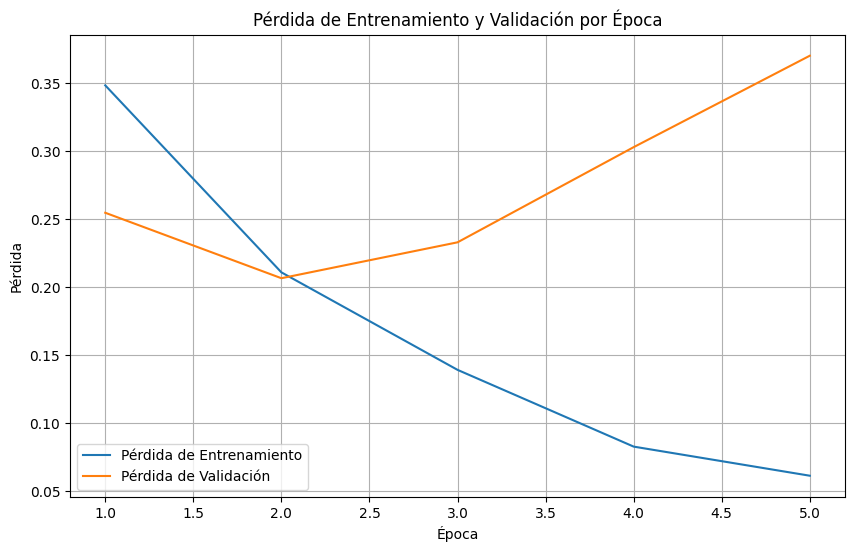

In [ ]:
# ---------------------------
# 8. Visualizar pérdidas
# ---------------------------
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Epoch'], metrics_df['Train Loss'], label='Pérdida de Entrenamiento')
plt.plot(metrics_df['Epoch'], metrics_df['Validation Loss'], label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

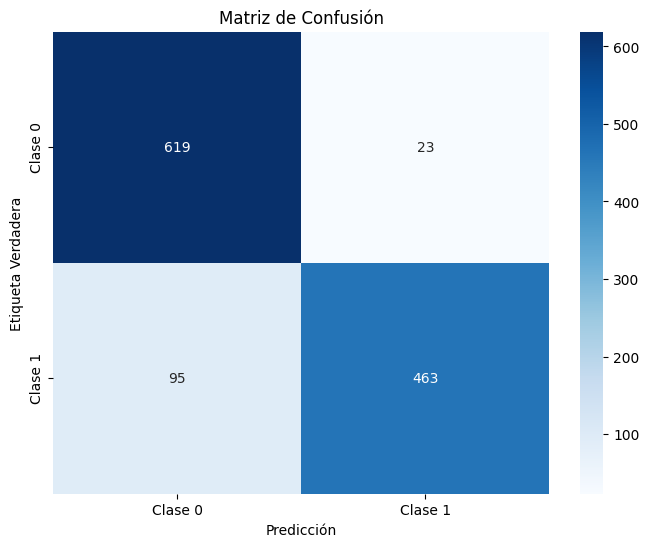

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 9. Obtener predicciones del mejor modelo en el conjunto de validación
# ---------------------------
model.eval() # Poner el modelo en modo evaluación
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_dataloader:
        input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask, features)
        preds = torch.argmax(outputs, axis=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---------------------------
# 10. Generar y graficar la matriz de confusión
# ---------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()